# 1. Configuration and Imports

In [2]:
import librosa
import numpy as np
from pathlib import Path
from typing import Union
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Feature Extraction Function Definitions

In [4]:
def extract_features(file_path: Union[str, Path], n_mfcc=13):
    """Extracts the average MFCC from an audio file."""

    y, sr = librosa.load(str(file_path), sr=16000)
    # Calculate MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Average each feature to have one vector per file
    return np.mean(mfcc.T, axis=0)

def load_dataset(processed_path: Union[str, Path]):
    X, y = [], []
    processed_dir = Path(processed_path)
     # Mapping folder names to numbers (labels)
    label_map = {"tv": 0, "talk": 1, "yell": 2}
    
    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        label = label_map.get(category_dir.name)
        if label is None:
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

# 3. Preparing the Data Set

In [5]:
X, y = load_dataset('../data/processed')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Number of samples in X: {len(X)}")
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Unique labels in y: {np.unique(y)}")

c:\Users\emill\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of samples in X: 688
Training set size: (550, 13)
Test set size: (138, 13)
Unique labels in y: [0 1 2]


# 4. Training a Random Forest Model

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=7)
model.fit(X=X_train,y=y_train)

y_pred = model.predict(X=X_test)
target_names = ['TV', 'Talk', 'Yell']

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 99.28%
              precision    recall  f1-score   support

          TV       1.00      1.00      1.00         5
        Talk       1.00      0.67      0.80         3
        Yell       0.99      1.00      1.00       130

    accuracy                           0.99       138
   macro avg       1.00      0.89      0.93       138
weighted avg       0.99      0.99      0.99       138



# 5. Confusion Matrix Chart

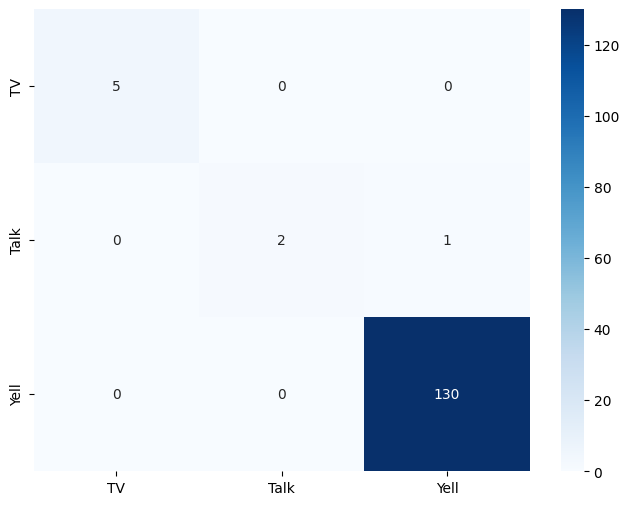

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.show()